In [2]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
import glob

data_dir = "../attention_data"

def load_all_attention(data_dir):
    """Load all saved attention data into lists."""
    samples = []
    shard_files = sorted(glob.glob(os.path.join(data_dir, "shard_*.h5")))
    
    for shard_path in shard_files:
        with h5py.File(shard_path, "r") as f:
            for key in sorted(f.keys()):
                grp = f[key]
                samples.append({
                    "prompt": grp.attrs["prompt"],
                    "seq_len": int(grp.attrs["seq_len"]),
                    "num_bands": int(grp.attrs["num_bands"]),
                    "band_attn": grp["band_attn"][:].astype(np.float32),
                    "band_ranges": grp["band_ranges"][:],
                })
    
    return samples

samples = load_all_attention(data_dir)
print("Loaded {} samples".format(len(samples)))
print("Num bands: {}".format(samples[0]["num_bands"]))

Loaded 2 samples
Num bands: 7


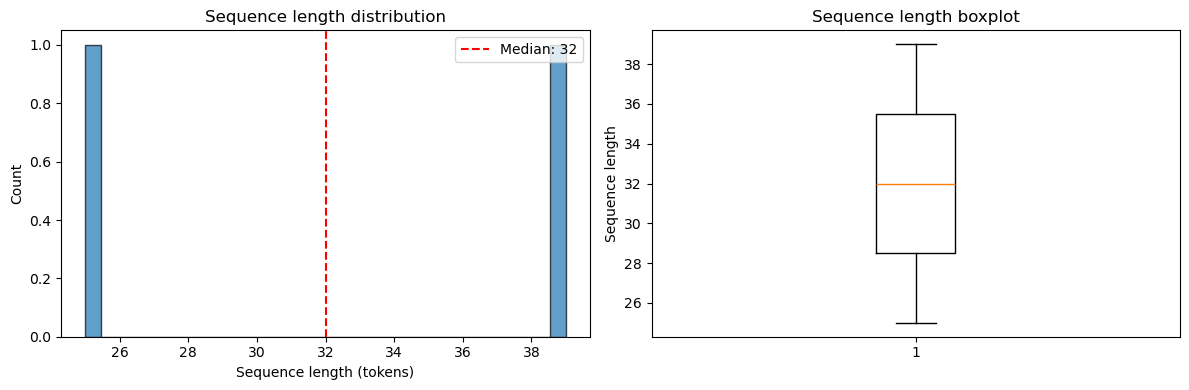

Min: 25, Max: 39, Mean: 32.0, Median: 32


In [3]:
seq_lens = [s["seq_len"] for s in samples]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(seq_lens, bins=30, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Sequence length (tokens)")
axes[0].set_ylabel("Count")
axes[0].set_title("Sequence length distribution")
axes[0].axvline(np.median(seq_lens), color="red", linestyle="--",
                label="Median: {}".format(int(np.median(seq_lens))))
axes[0].legend()

axes[1].boxplot(seq_lens, vert=True)
axes[1].set_ylabel("Sequence length")
axes[1].set_title("Sequence length boxplot")

plt.tight_layout()
plt.show()

print("Min: {}, Max: {}, Mean: {:.1f}, Median: {}".format(
    min(seq_lens), max(seq_lens), np.mean(seq_lens), int(np.median(seq_lens))))

In [4]:
def compute_attn_stats(attn_matrix, seq_len):
    """Compute summary statistics for a single (padded) attention matrix.
    
    Only considers the top-left seq_len x seq_len block (real data).
    """
    a = attn_matrix[:seq_len, :seq_len]
    
    # Basic stats
    mean_val = a.mean()
    std_val = a.std()
    frob_norm = np.linalg.norm(a, "fro")
    max_val = a.max()
    
    # Row entropy: how spread out is each token's attention?
    row_entropies = []
    for row in a:
        row_clipped = np.clip(row, 1e-10, None)
        row_entropies.append(-np.sum(row_clipped * np.log(row_clipped)))
    mean_row_entropy = np.mean(row_entropies)
    std_row_entropy = np.std(row_entropies)
    
    # Diagonal dominance: average attention to self
    diag_mean = np.mean(np.diag(a))
    
    # First column mean: attention to first token (BOS sink)
    first_col_mean = a[:, 0].mean()
    
    # Off-diagonal mean (excluding self-attention)
    mask = ~np.eye(seq_len, dtype=bool)
    off_diag_mean = a[mask].mean() if seq_len > 1 else 0.0
    
    return {
        "mean": mean_val,
        "std": std_val,
        "frob_norm": frob_norm,
        "max": max_val,
        "mean_row_entropy": mean_row_entropy,
        "std_row_entropy": std_row_entropy,
        "diag_mean": diag_mean,
        "first_col_mean": first_col_mean,
        "off_diag_mean": off_diag_mean,
    }


num_bands = samples[0]["num_bands"]

# Compute stats: band_stats[band_idx] = list of stat dicts
band_stats = {}
for band_idx in range(num_bands):
    band_stats[band_idx] = []
    for s in samples:
        stats = compute_attn_stats(s["band_attn"][band_idx], s["seq_len"])
        band_stats[band_idx].append(stats)

print("Computed stats for {} bands x {} samples".format(num_bands, len(samples)))

Computed stats for 7 bands x 2 samples


/tmp/ipykernel_1944156/1796482458.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_per_band, labels=labels)
/tmp/ipykernel_1944156/1796482458.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_per_band, labels=labels)
/tmp/ipykernel_1944156/1796482458.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_per_band, labels=labels)
/tmp/ipykernel_1944156/1796482458.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_per_band, lab

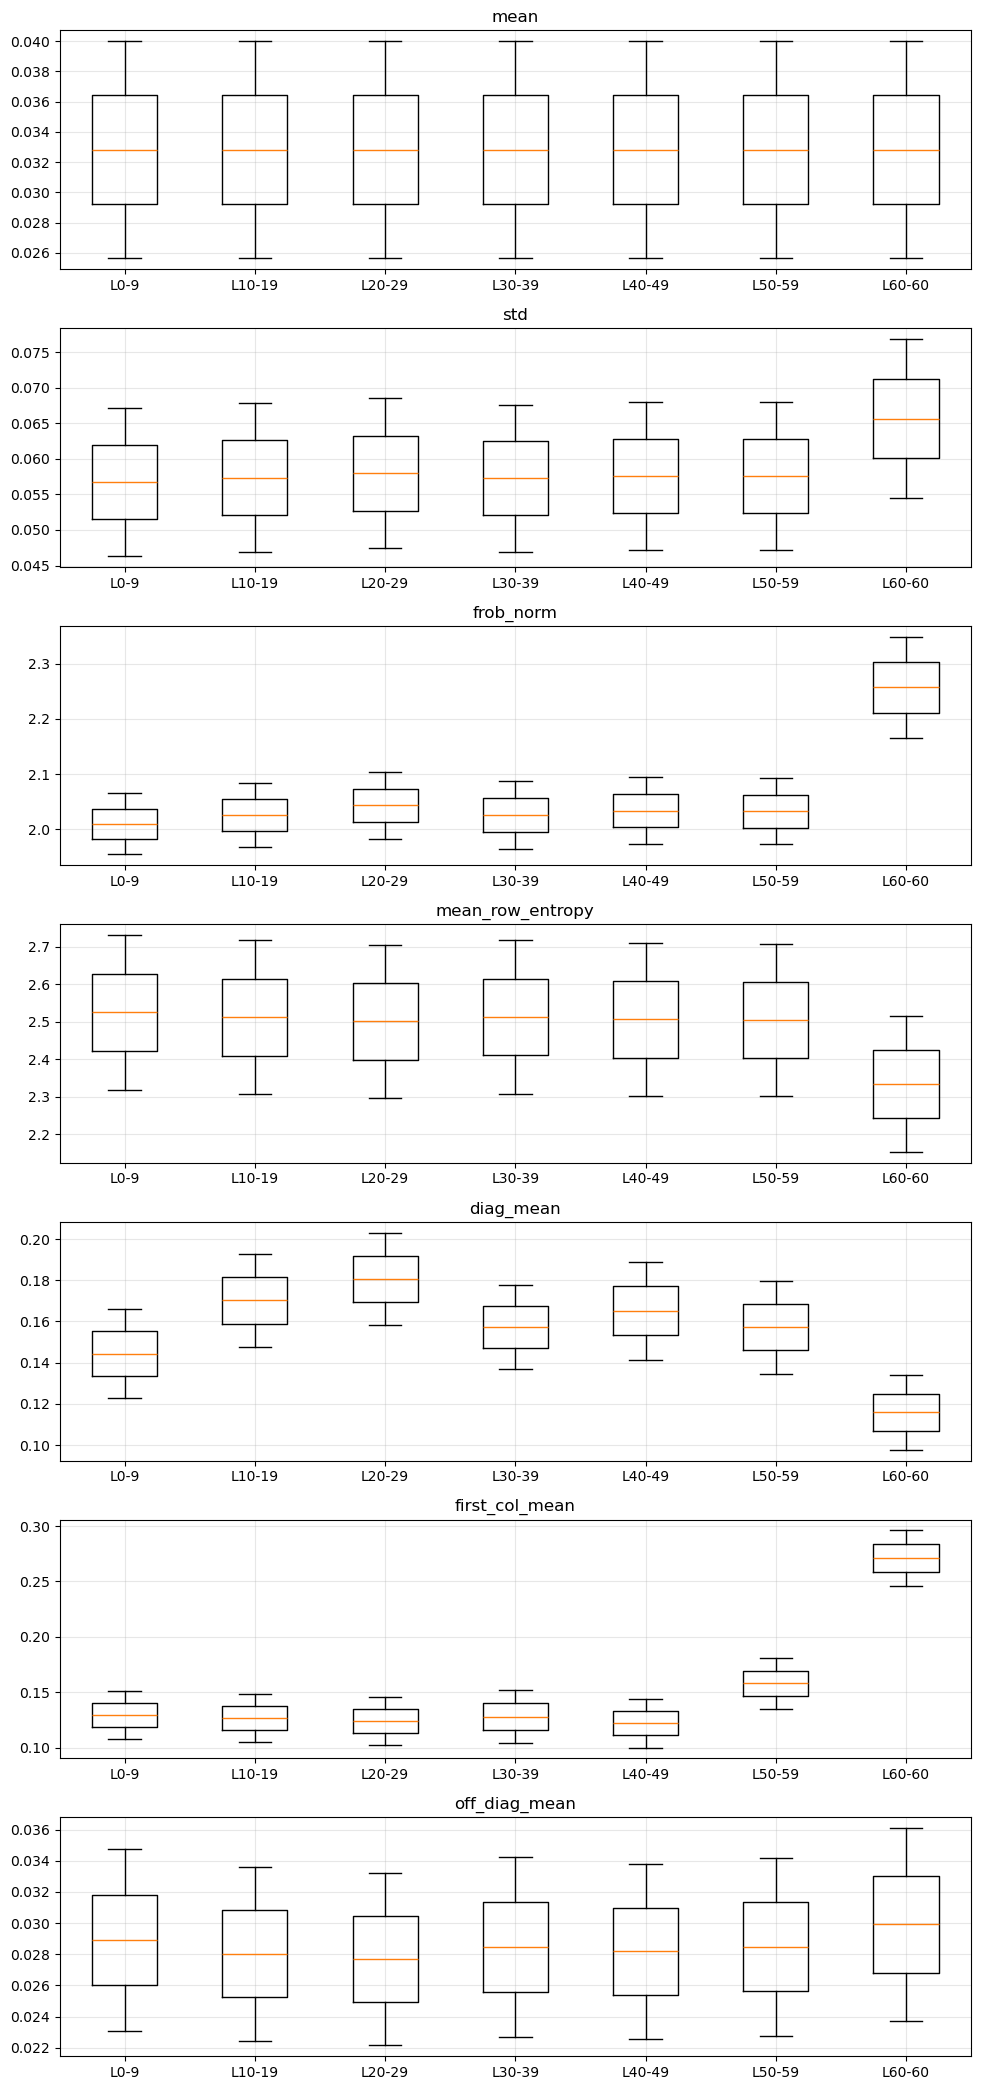

In [5]:
stat_names = ["mean", "std", "frob_norm", "mean_row_entropy",
              "diag_mean", "first_col_mean", "off_diag_mean"]

fig, axes = plt.subplots(len(stat_names), 1, figsize=(10, 3 * len(stat_names)))

for row, stat_name in enumerate(stat_names):
    ax = axes[row]
    
    data_per_band = []
    labels = []
    for band_idx in range(num_bands):
        values = [s[stat_name] for s in band_stats[band_idx]]
        data_per_band.append(values)
        start, end = samples[0]["band_ranges"][band_idx]
        labels.append("L{}-{}".format(start, end - 1))
    
    ax.boxplot(data_per_band, labels=labels)
    ax.set_title(stat_name)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

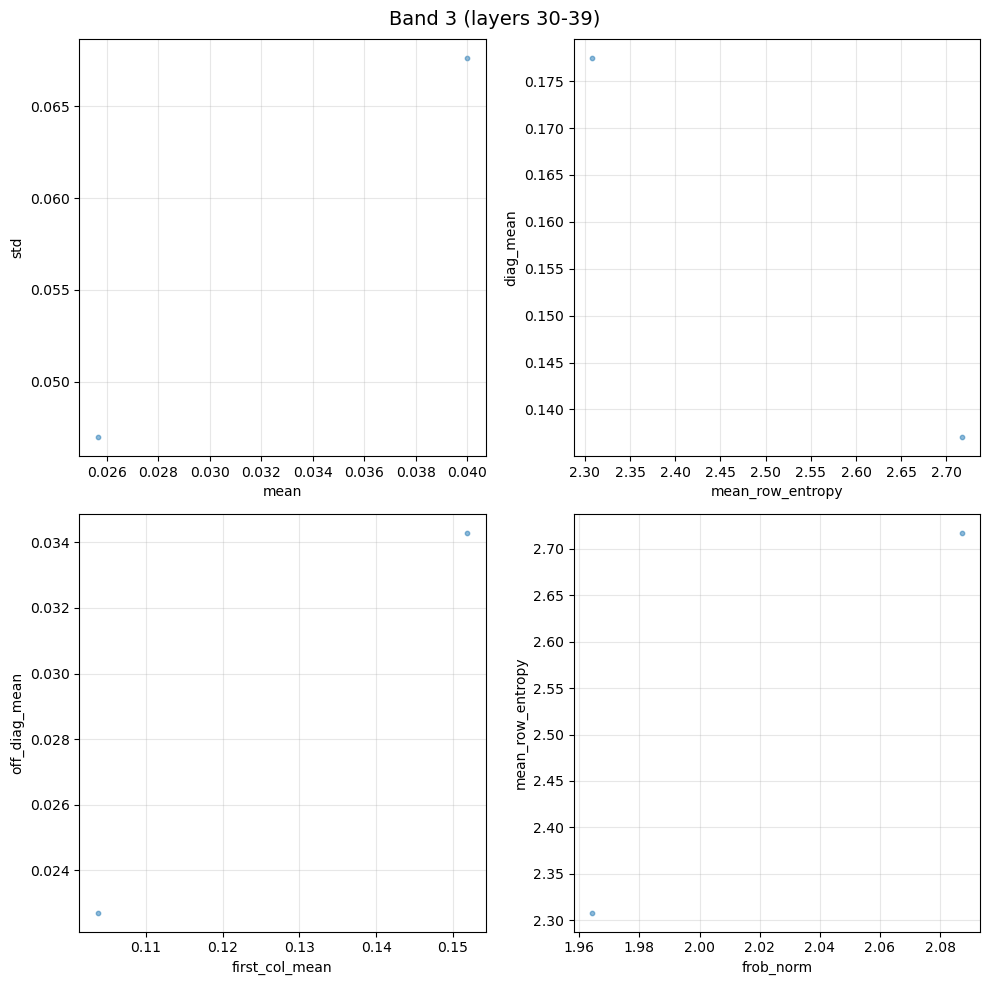

In [6]:
target_band = 3  # pick a middle band to inspect

stats_list = band_stats[target_band]
pairs = [
    ("mean", "std"),
    ("mean_row_entropy", "diag_mean"),
    ("first_col_mean", "off_diag_mean"),
    ("frob_norm", "mean_row_entropy"),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for ax, (x_name, y_name) in zip(axes.flat, pairs):
    x_vals = [s[x_name] for s in stats_list]
    y_vals = [s[y_name] for s in stats_list]
    ax.scatter(x_vals, y_vals, alpha=0.5, s=10)
    ax.set_xlabel(x_name)
    ax.set_ylabel(y_name)
    ax.grid(True, alpha=0.3)

start, end = samples[0]["band_ranges"][target_band]
fig.suptitle("Band {} (layers {}-{})".format(target_band, start, end - 1), fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
print("{:<25s} {:>10s}  {:>10s}  {:>10s}".format(
    "Statistic", "Mean", "Std", "CV (%)"))
print("-" * 60)

for stat_name in stat_names:
    for band_idx in [0, 3, 6]:  # early, middle, late band
        values = np.array([s[stat_name] for s in band_stats[band_idx]])
        mean = values.mean()
        std = values.std()
        cv = 100 * std / abs(mean) if abs(mean) > 1e-10 else float("inf")
        
        start, end = samples[0]["band_ranges"][band_idx]
        label = "{} (L{}-{})".format(stat_name, start, end - 1)
        print("{:<25s} {:>10.4f}  {:>10.4f}  {:>10.1f}".format(label, mean, std, cv))
    print()

Statistic                       Mean         Std      CV (%)
------------------------------------------------------------
mean (L0-9)                   0.0328      0.0072        21.9
mean (L30-39)                 0.0328      0.0072        21.9
mean (L60-60)                 0.0328      0.0072        21.9

std (L0-9)                    0.0568      0.0104        18.4
std (L30-39)                  0.0573      0.0103        18.0
std (L60-60)                  0.0657      0.0112        17.0

frob_norm (L0-9)              2.0101      0.0549         2.7
frob_norm (L30-39)            2.0257      0.0614         3.0
frob_norm (L60-60)            2.2569      0.0913         4.0

mean_row_entropy (L0-9)       2.5251      0.2067         8.2
mean_row_entropy (L30-39)     2.5124      0.2043         8.1
mean_row_entropy (L60-60)     2.3334      0.1807         7.7

diag_mean (L0-9)              0.1444      0.0217        15.0
diag_mean (L30-39)            0.1573      0.0202        12.9
diag_mean (L60-60)  